In [1]:
#Task 1 — Data Loading, Merging & Deep Exploration

In [2]:
# Load the Superstore Sales CSV using Pandas
import kagglehub
import pandas as pd
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

print("Path to dataset files:", path)

# List all files in the downloaded folder
print(os.listdir(path))

# Load the CSV file
df = pd.read_csv(os.path.join(path, "train.csv"))

# Display the first 5 rows
print(df.head())



C:\Users\AKHIL\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\AKHIL\.cache\kagglehub\datasets\rohitsahoo\sales-forecasting\versions\2
['train.csv']
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O

In [3]:
# Convert Order Date and Ship Date to datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Display the converted columns
print(df[["Order Date", "Ship Date"]].head())

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


In [4]:
#Extract time features
# ---------- Order Date Features ----------
df["Order_Year"] = df["Order Date"].dt.year.astype("Int64")
df["Order_Month"] = df["Order Date"].dt.month.astype("Int64")
df["Order_Week"] = df["Order Date"].dt.isocalendar().week.astype("Int64")
df["Order_DayOfWeek"] = df["Order Date"].dt.dayofweek.astype("Int64")  # Monday=0, Sunday=6
df["Order_Quarter"] = df["Order Date"].dt.quarter.astype("Int64")

# ---------- Ship Date Features ----------
df["Ship_Year"] = df["Ship Date"].dt.year.astype("Int64")
df["Ship_Month"] = df["Ship Date"].dt.month.astype("Int64")
df["Ship_Week"] = df["Ship Date"].dt.isocalendar().week.astype("Int64")
df["Ship_DayOfWeek"] = df["Ship Date"].dt.dayofweek.astype("Int64")    # Monday=0, Sunday=6
df["Ship_Quarter"] = df["Ship Date"].dt.quarter.astype("Int64")

def get_season(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    else:
        return 4  # Autumn  

df["Order_Season"] = df["Order_Month"].apply(get_season)
df["Ship_Season"] = df["Ship_Month"].apply(get_season)
print(df[[
    "Order_Year", "Order_Month", "Order_Week", "Order_DayOfWeek", "Order_Quarter", "Order_Season",
    "Ship_Year", "Ship_Month", "Ship_Week", "Ship_DayOfWeek", "Ship_Quarter", "Ship_Season"
]].head())

   Order_Year  Order_Month  Order_Week  Order_DayOfWeek  Order_Quarter  \
0        2017           11          45                2              4   
1        2017           11          45                2              4   
2        2017            6          24                0              2   
3        2016           10          41                1              4   
4        2016           10          41                1              4   

   Order_Season  Ship_Year  Ship_Month  Ship_Week  Ship_DayOfWeek  \
0             4       2017          11         45               5   
1             4       2017          11         45               5   
2             3       2017           6         24               4   
3             4       2016          10         42               1   
4             4       2016          10         42               1   

   Ship_Quarter  Ship_Season  
0             4            4  
1             4            4  
2             2            3  
3             4 

In [5]:
#Check for missing values, duplicates, and data type issues
# Check missing values in each column
print("Missing Values:\n")
print(df.isnull().sum())

# Count duplicate rows
print("Number of Duplicate Rows:", df.duplicated().sum())

# Display data types of all columns
print(df.dtypes)


Missing Values:

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code        11
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Order_Year          0
Order_Month         0
Order_Week          0
Order_DayOfWeek     0
Order_Quarter       0
Ship_Year           0
Ship_Month          0
Ship_Week           0
Ship_DayOfWeek      0
Ship_Quarter        0
Order_Season        0
Ship_Season         0
dtype: int64
Number of Duplicate Rows: 0
Row ID                      int64
Order ID                      str
Order Date         datetime64[us]
Ship Date          datetime64[us]
Ship Mode                     str
Customer ID                   str
Customer Name                 str
Segment                       str
Country   

In [6]:
# Weekly Sales Aggregation
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

print("Weekly Sales:")
print(weekly_sales.head())

# Monthly Sales Aggregation
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

print("Monthly Sales:")
print(monthly_sales.head())



Weekly Sales:
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914
Monthly Sales:
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


In [8]:
#1.Which product category generates the highest total revenue?
# Total revenue by category
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

"""Technology  product category generates the highest total revenue( 827455.8730)"""

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


'Technology  product category generates the highest total revenue( 827455.8730)'

In [9]:
#2. Which region has the most consistent sales growth over 4 years?
region_year_sales = (
    df.groupby(["Order_Year", "Region"])["Sales"]
      .sum()
      .unstack()
)

print(region_year_sales)
"""The Central region has the most consistent sales growth over the four-year period."""

Region          Central        East        South         West
Order_Year                                                   
2015        102920.5206  127652.819  103374.9055  145907.9630
2016        102425.1724  153225.183   70076.0825  133709.5675
2017        145673.8800  178511.538   93535.9035  182471.2285
2018        141627.3402  210129.186  122164.5675  248130.9255


'The Central region has the most consistent sales growth over the four-year period.'

In [10]:
#3.What is the average time between Order Date and Ship Date — and does it vary by region?
# Calculate shipping time in days
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days.astype("Int64")
#Overall average shipping time
overall_avg = df["Shipping Days"].mean()
print("Average Shipping Time:", round(overall_avg, 2), "days")

# Average shipping time by region
shipping_by_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

print(shipping_by_region)

Average Shipping Time: 3.96 days
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: Float64


In [11]:
#4.Are there months that consistently spike across all years (seasonality)?
season_sales = (
    df.groupby("Order_Season")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(season_sales)

#1 Winter
#2 Spring
#3 Summer
#4 Autumn  

"""Autumn generated the highest total sales (849,761.42), significantly outperforming the other seasons"""

Order_Season
4    849761.4174
2    487943.3115
1    475142.9145
3    448689.1393
Name: Sales, dtype: float64


'Autumn generated the highest total sales (849,761.42), significantly outperforming the other seasons'

In [12]:
#Task 2 — Time Series Analysis & Decomposition

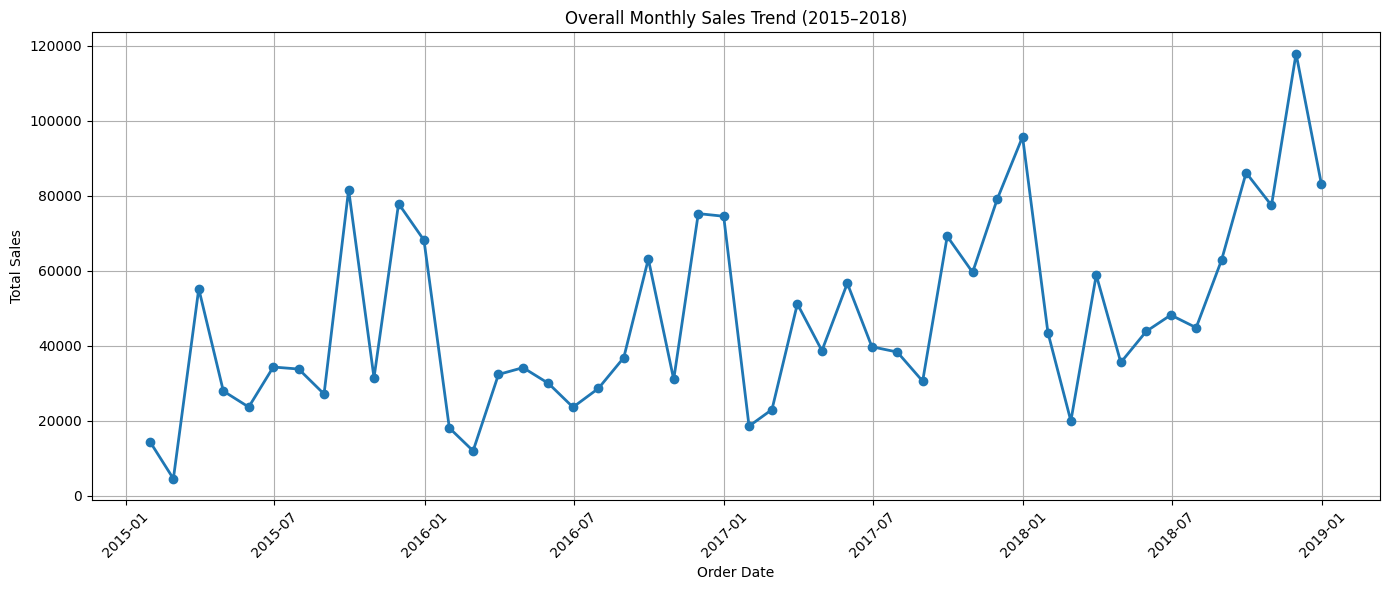

In [13]:
# overall monthly sales trend across all 4 years
import matplotlib.pyplot as plt

# Aggregate monthly sales
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

# Plot monthly sales trend
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"],
         marker="o", linewidth=2)

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


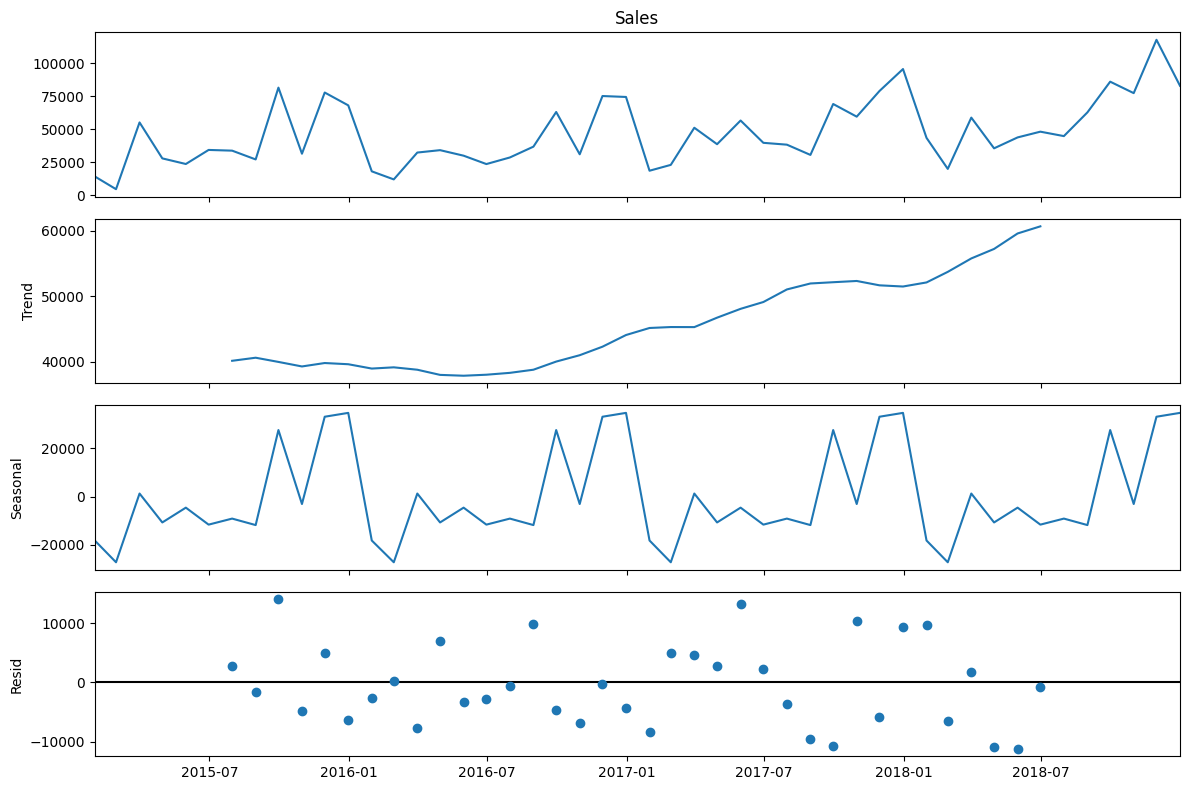

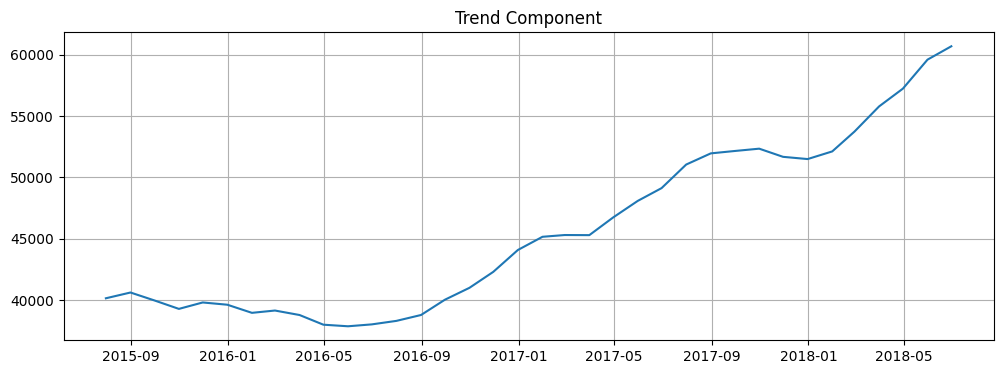

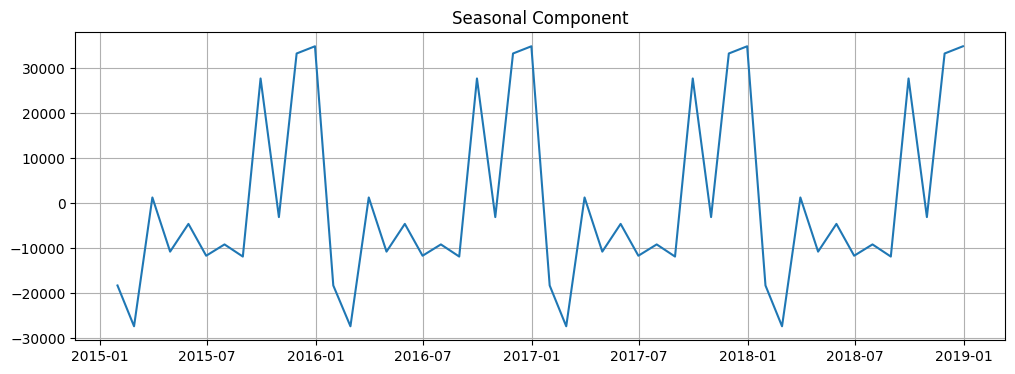

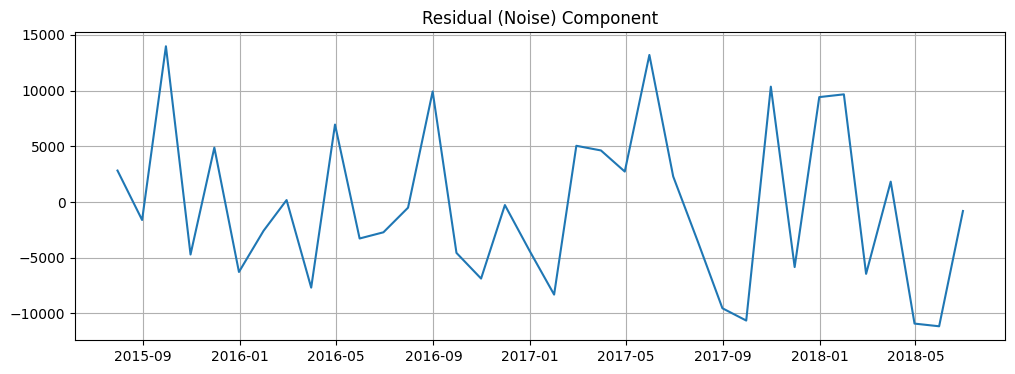

In [14]:
#Time Series Decomposition

#Import the required library
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Monthly sales time series
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

print(monthly_sales.head())

# Perform additive decomposition
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

#Trend Component Visualization
plt.figure(figsize=(12,4))
plt.plot(decomposition.trend)
plt.title("Trend Component")
plt.grid(True)
plt.show()

#Seasonal Component Visualization
plt.figure(figsize=(12,4))
plt.plot(decomposition.seasonal)
plt.title("Seasonal Component")
plt.grid(True)
plt.show()

#Residual Component Visualization
plt.figure(figsize=(12,4))
plt.plot(decomposition.resid)
plt.title("Residual (Noise) Component")
plt.grid(True)
plt.show()

In [15]:
"""Observation 1: Trend

The trend component shows a steady upward growth in sales from 2015 to 2018. 
Although sales remained relatively stable during the early years, they increased
significantly from 2017 onwards, indicating continuous business growth and rising
customer demand.

Observation 2: Seasonality

The seasonal component exhibits a strong and recurring yearly pattern. The seasonal
fluctuations repeat consistently every 12 months, confirming that sales are strongly 
influenced by seasonal factors rather than random variation.

Observation 3: Residual (Noise)

The residual component is centered around zero, meaning most of the variation in 
sales is explained by the trend and seasonality. However, a few months show unusually
large positive or negative residuals, indicating unexpected events such as promotions, 
discounts, holidays, or supply chain issues.

Observation 4: Months with Highest Residual Noise

Based on the residual plot, the largest positive residuals occur around late 2015,
mid-2017, and late 2017 to early 2018, while the largest negative residuals appear around 
late 2017 and mid-2018. These months experienced sales that were significantly higher
or lower than expected after accounting for the trend and seasonal effects, suggesting
the influence of one-time business events or market conditions."""

'Observation 1: Trend\n\nThe trend component shows a steady upward growth in sales from 2015 to 2018. \nAlthough sales remained relatively stable during the early years, they increased\nsignificantly from 2017 onwards, indicating continuous business growth and rising\ncustomer demand.\n\nObservation 2: Seasonality\n\nThe seasonal component exhibits a strong and recurring yearly pattern. The seasonal\nfluctuations repeat consistently every 12 months, confirming that sales are strongly \ninfluenced by seasonal factors rather than random variation.\n\nObservation 3: Residual (Noise)\n\nThe residual component is centered around zero, meaning most of the variation in \nsales is explained by the trend and seasonality. However, a few months show unusually\nlarge positive or negative residuals, indicating unexpected events such as promotions, \ndiscounts, holidays, or supply chain issues.\n\nObservation 4: Months with Highest Residual Noise\n\nBased on the residual plot, the largest positive r

In [16]:
#Augmented Dickey-Fuller (ADF) Test

#Import the ADF Test
from statsmodels.tsa.stattools import adfuller
# Perform ADF Test
adf_result = adfuller(monthly_sales)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

# interpretation of the ADF test result
if adf_result[1] < 0.05:
    print("\nResult: The time series is stationary.")
else:
    print("\nResult: The time series is NOT stationary.")



ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Number of Lags Used: 0
Number of Observations: 47

Critical Values:
1%: -3.5778
5%: -2.9253
10%: -2.6008

Result: The time series is stationary.


In [17]:
"""What is Stationarity?

Stationarity means that the statistical properties of a time series—such as 
its average (mean), variation (variance), and seasonal behavior—remain 
relatively constant over time. In other words, the data follows a stable
pattern without a long-term upward or downward trend."""

"""Conclusion 

The Augmented Dickey-Fuller (ADF) test was performed to determine whether 
the monthly sales data is stationary. Stationarity means that the statistical 
properties of the time series, such as its mean and variance, remain 
relatively stable over time. The test produced an ADF statistic of
-4.4161 and a p-value of 0.000278, which is less than the significance level
of 0.05. Therefore, the null hypothesis was rejected, indicating that the
monthly sales time series is stationary. This suggests that the data is
suitable for time-series forecasting models such as ARIMA, without
requiring additional differencing to achieve stationarity."""

'Conclusion \n\nThe Augmented Dickey-Fuller (ADF) test was performed to determine whether \nthe monthly sales data is stationary. Stationarity means that the statistical \nproperties of the time series, such as its mean and variance, remain \nrelatively stable over time. The test produced an ADF statistic of\n-4.4161 and a p-value of 0.000278, which is less than the significance level\nof 0.05. Therefore, the null hypothesis was rejected, indicating that the\nmonthly sales time series is stationary. This suggests that the data is\nsuitable for time-series forecasting models such as ARIMA, without\nrequiring additional differencing to achieve stationarity.'

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64


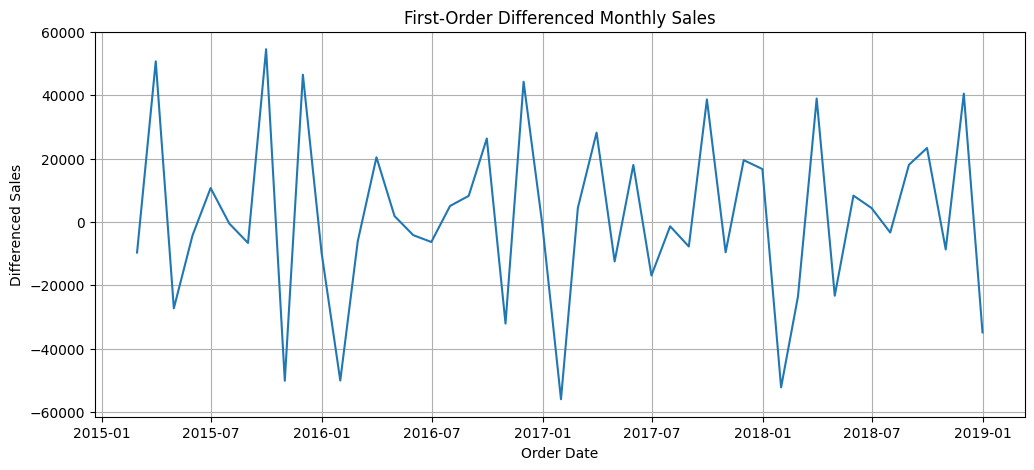

ADF Statistic: -8.72706183035327
p-value: 3.2669175472796045e-14

Critical Values:
1%: -3.6267
5%: -2.9460
10%: -2.6117


In [18]:
#Apply differencing if the series is non-stationary and re-test

#for the conformation of stationarity
# First-order differencing
monthly_sales_diff = monthly_sales.diff().dropna()

print(monthly_sales_diff.head())

#Plot the Differenced Series

plt.figure(figsize=(12,5))
plt.plot(monthly_sales_diff)
plt.title("First-Order Differenced Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.show()

#Re-test Using the ADF Test
adf_diff = adfuller(monthly_sales_diff)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}: {value:.4f}")

In [19]:
#Task 3 — Sales Forecasting using 3 Different Models

In [52]:
# =====================================
# Model 1 — SARIMA
# =====================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Select only the Sales column
sales_series = monthly_sales["Sales"]

# Train-Test Split (80:20)
train_size = int(len(sales_series) * 0.8)

train = sales_series.iloc[:train_size]
test = sales_series.iloc[train_size:]

print("Training Data:", len(train))
print("Testing Data:", len(test))

# Build SARIMA Model
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

# Forecast on Test Data
sarima_forecast = sarima_result.forecast(steps=len(test))

print("Forecast:")
print(sarima_forecast)

# Evaluate Model
sarima_mae = mean_absolute_error(test, sarima_forecast)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_forecast)
)

sarima_mape = np.mean(
    np.abs((test - sarima_forecast) / test)
) * 100

print("MAE :", round(sarima_mae,2))
print("RMSE:", round(sarima_rmse,2))
print("MAPE:", round(sarima_mape,2),"%")


Training Data: 38
Testing Data: 10
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -118.582
Date:                            Sun, 12 Jul 2026   AIC                            247.163
Time:                                    19:16:59   BIC                            249.153
Sample:                                         0   HQIC                           245.909
                                             - 38                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2499      0.668     -0.374      0.708      -1.559       1.059


C:\Users\AKHIL\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [22]:
"""| Parameter  | Value | Reason                                                                                                        |
| ----------    | ----- | ------------------------------------------------------------------------------------------------------------- |
| **p = 1**     | 1     | Assumes the current month's sales depend on the previous month's sales (one autoregressive lag).              |
| **d = 1**     | 1     | First-order differencing was selected to remove any remaining trend and stabilize the series before modeling. |
| **q = 1**     | 1     | Includes one moving average term to capture the effect of previous forecast errors.                           |
| **P = 1**     | 1     | Accounts for yearly seasonal autoregressive effects.                                                          |
| **D = 1**     | 1     | Seasonal differencing removes yearly seasonal patterns (12-month cycle).                                      |
| **Q = 1**     | 1     | Captures seasonal forecast errors from the previous year.                                                     |
| **m = 12**    | 12    | The data is monthly, so one seasonal cycle consists of 12 months.                                             |"""


"| Parameter  | Value | Reason                                                                                                        |\n| ----------    | ----- | ------------------------------------------------------------------------------------------------------------- |\n| **p = 1**     | 1     | Assumes the current month's sales depend on the previous month's sales (one autoregressive lag).              |\n| **d = 1**     | 1     | First-order differencing was selected to remove any remaining trend and stabilize the series before modeling. |\n| **q = 1**     | 1     | Includes one moving average term to capture the effect of previous forecast errors.                           |\n| **P = 1**     | 1     | Accounts for yearly seasonal autoregressive effects.                                                          |\n| **D = 1**     | 1     | Seasonal differencing removes yearly seasonal patterns (12-month cycle).                                      |\n| **Q = 1**     | 1     | Cap

In [54]:
#3-month future forecast with confidence intervals
# Forecast the next 3 months
sarima_future_forecast = sarima_result.get_forecast(steps=3)

sarima_future_values = sarima_future_forecast.predicted_mean

print("Next 3 Months Forecast:")

print(sarima_future_values)

# 95% Confidence Intervals
confidence_intervals = sarima_future_forecast.conf_int()

print("95% Confidence Intervals:")

print(confidence_intervals)

Next 3 Months Forecast:
38    65967.980554
39    49975.622654
40    67126.476879
Name: predicted_mean, dtype: float64
95% Confidence Intervals:
     lower Sales   upper Sales
38  40347.906595  91588.054513
39  23771.868376  76179.376932
40  40833.812003  93419.141755


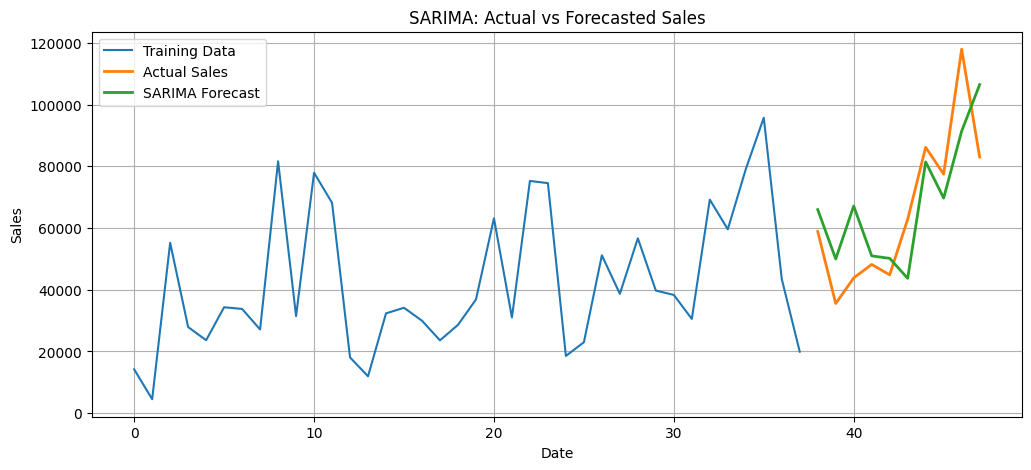

In [55]:
# Plot Actual vs Forecasted Sales

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Training data
plt.plot(train.index, train, label="Training Data")

# Actual test data
plt.plot(test.index, test, label="Actual Sales", linewidth=2)

# Forecasted test data
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast", linewidth=2)

plt.title("SARIMA: Actual vs Forecasted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# =====================================
# Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)
#=====================================

In [56]:
# Prepare data for Prophet

prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

print(prophet_df.head())

          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


In [ ]:
# Fit the model and generate a 3-month forecast

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Create monthly sales DataFrame
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"), as_index=False)["Sales"]
      .sum()
)

print(type(monthly_sales))
print(monthly_sales.head())

# Prepare data for Prophet
prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

# Create Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Fit the model
prophet_model.fit(prophet_df)

# Create future dates (3 months)
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

# Predict
prophet_forecast = prophet_model.predict(future)

# Display next 3 months forecast
future_forecast = prophet_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

print("3-Month Forecast:")
print(future_forecast)

# Evaluate Prophet Model

# Actual values
actual = prophet_df["y"]

# Predicted values for historical data
predicted = prophet_forecast["yhat"].iloc[:len(actual)]

# Metrics
prophet_mae = mean_absolute_error(actual, predicted)
prophet_rmse = np.sqrt(mean_squared_error(actual, predicted))
prophet_mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("\nProphet Model Performance")
print("MAE :", round(prophet_mae, 2))
print("RMSE:", round(prophet_rmse, 2))
print("MAPE:", round(prophet_mape, 2), "%")

19:25:38 - cmdstanpy - INFO - Chain [1] start processing


<class 'pandas.DataFrame'>
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


19:25:38 - cmdstanpy - INFO - Chain [1] done processing


3-Month Forecast:
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  42990.532202  34047.120455  51651.327777
49 2019-02-28  31248.159922  21894.446489  40328.830620
50 2019-03-31  81267.007772  71582.587805  89884.763844

Prophet Model Performance
MAE : 5770.42
RMSE: 7272.0
MAPE: 14.48 %


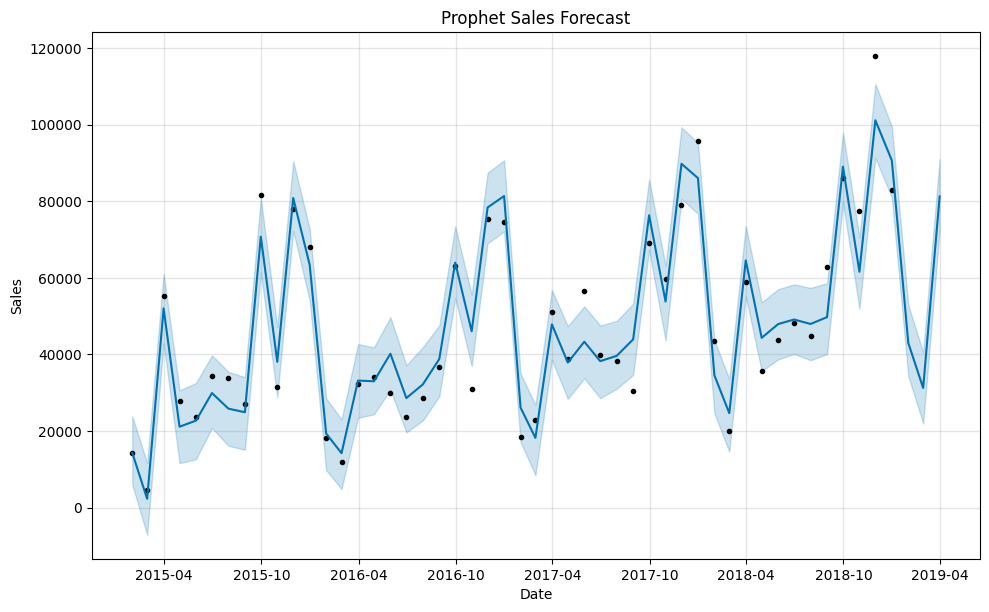

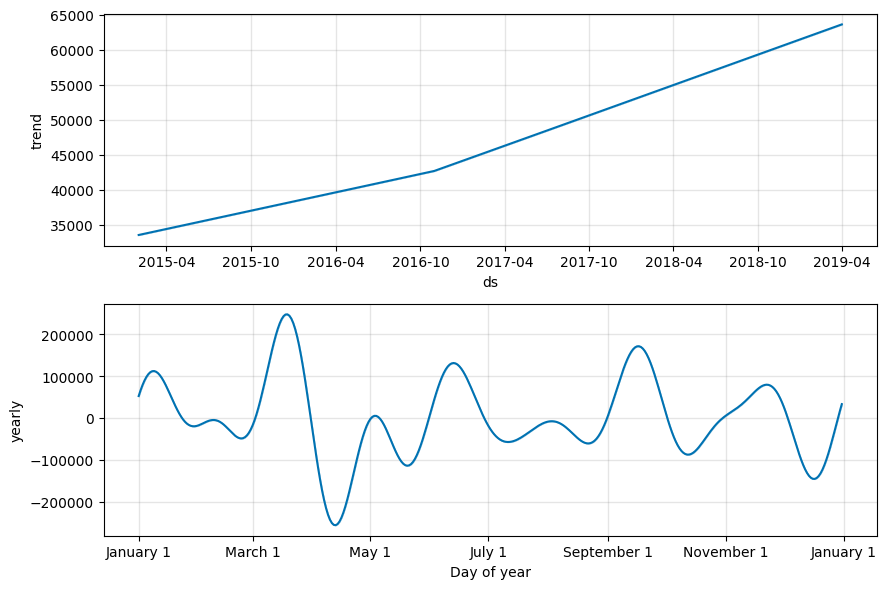

In [63]:
#Plot the forecast with Prophet's built-in trend and seasonality breakdown
# Plot the forecast
import matplotlib.pyplot as plt

fig1 = prophet_model.plot(forecast)
plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# Plot Prophet's built-in trend and seasonality breakdown
fig2 = prophet_model.plot_components(forecast)
plt.show()



In [34]:

"""Yearly Seasonality

The yearly seasonality component shows how sales change throughout the year. 
Positive values indicate months where sales are generally above the yearly 
average, while negative values indicate months with lower-than-average sales.
 This recurring pattern helps identify peak and low-demand periods, enabling 
 better inventory planning and forecasting.

Weekly Seasonality

Weekly seasonality cannot be interpreted in this project because the sales
 data was aggregated to monthly totals before training the Prophet model.
   Since each observation represents an entire month rather than individual 
   days, Prophet does not estimate weekly patterns."""

'Yearly Seasonality\n\nThe yearly seasonality component shows how sales change throughout the year. \nPositive values indicate months where sales are generally above the yearly \naverage, while negative values indicate months with lower-than-average sales.\n This recurring pattern helps identify peak and low-demand periods, enabling \n better inventory planning and forecasting.\n\nWeekly Seasonality\n\nWeekly seasonality cannot be interpreted in this project because the sales\n data was aggregated to monthly totals before training the Prophet model.\n   Since each observation represents an entire month rather than individual \n   days, Prophet does not estimate weekly patterns.'

In [ ]:
#============================
#Model 3 — XGBoost for Time Series (ML-based Approach)
#============================

In [36]:
# Convert time series into a supervised ML dataset

import pandas as pd

# Create a copy
ml_data = monthly_sales.copy()

# -------------------------
# Lag Features
# -------------------------
ml_data["Lag_1"] = ml_data["Sales"].shift(1)
ml_data["Lag_2"] = ml_data["Sales"].shift(2)
ml_data["Lag_3"] = ml_data["Sales"].shift(3)

# -------------------------
# Rolling Mean (3-Month Moving Average)
# Uses only previous months to avoid data leakage
# -------------------------
ml_data["Rolling_Mean_3"] = (
    ml_data["Sales"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# -------------------------
# Date-based Features
# -------------------------
ml_data["Month"] = ml_data["Order Date"].dt.month
ml_data["Quarter"] = ml_data["Order Date"].dt.quarter

# Season Feature
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

ml_data["Season"] = ml_data["Month"].apply(get_season)

# Convert Season to numeric values
ml_data["Season"] = ml_data["Season"].map({
    "Winter": 1,
    "Spring": 2,
    "Summer": 3,
    "Autumn": 4
})

# Remove rows with missing values created by lag/rolling features
ml_data = ml_data.dropna().reset_index(drop=True)

# Display the first few rows
print(ml_data.head())

  Order Date       Sales       Lag_1       Lag_2      Lag_3  Rolling_Mean_3  \
0 2015-04-30  27906.8550  55205.7970   4519.8920  14205.707    24643.798667   
1 2015-05-31  23644.3030  27906.8550  55205.7970   4519.892    29210.848000   
2 2015-06-30  34322.9356  23644.3030  27906.8550  55205.797    35585.651667   
3 2015-07-31  33781.5430  34322.9356  23644.3030  27906.855    28624.697867   
4 2015-08-31  27117.5365  33781.5430  34322.9356  23644.303    30582.927200   

   Month  Quarter  Season  
0      4        2       2  
1      5        2       2  
2      6        2       3  
3      7        3       3  
4      8        3       3  


In [65]:
# ==========================================
# Train XGBoost Regressor
# ==========================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features
X = ml_data[[
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]]

# Target
y = ml_data["Sales"]

# Train-Test Split (80:20)
train_size = int(len(ml_data) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# Create XGBoost Model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective="reg:squarederror",
    random_state=42
)

# Train the Model
xgb_model.fit(X_train, y_train)

# Predict on Test Data
predictions = xgb_model.predict(X_test)

print("Predicted Sales:")
print(predictions)

# ==========================================
# Evaluate the Model
# ==========================================

xgb_mae = mean_absolute_error(y_test, predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, predictions))
xgb_mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print("\nXGBoost Model Performance")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("MAPE:", round(xgb_mape, 2), "%")

Predicted Sales:
[45761.69  44671.91  36822.4   49787.39  46081.547 66284.16  50497.65
 85575.85  66385.75 ]

XGBoost Model Performance
MAE : 15553.2
RMSE: 18212.49
MAPE: 21.93 %


In [66]:
# Predict the next 3 months using recursive forecasting

future_predictions = []

# Get the latest values from the dataset
last_row = ml_data.iloc[-1].copy()

for i in range(3):

    # Create input for prediction
    X_future = pd.DataFrame({
        "Lag_1": [last_row["Lag_1"]],
        "Lag_2": [last_row["Lag_2"]],
        "Lag_3": [last_row["Lag_3"]],
        "Rolling_Mean_3": [last_row["Rolling_Mean_3"]],
        "Month": [(last_row["Month"] % 12) + 1],
        "Quarter": [((last_row["Quarter"]) % 4) + 1],
        "Season": [((last_row["Season"]) % 4) + 1]
    })

    # Predict next month's sales
    pred = xgb_model.predict(X_future)[0]

    future_predictions.append(pred)

    # Update lag features for the next prediction
    last_row["Lag_3"] = last_row["Lag_2"]
    last_row["Lag_2"] = last_row["Lag_1"]
    last_row["Lag_1"] = pred

    # Update rolling mean
    last_row["Rolling_Mean_3"] = (
        last_row["Lag_1"] +
        last_row["Lag_2"] +
        last_row["Lag_3"]
    ) / 3

    # Update month
    last_row["Month"] = (last_row["Month"] % 12) + 1

    # Update quarter
    last_row["Quarter"] = ((last_row["Month"] - 1) // 3) + 1

    # Update season
    if last_row["Month"] in [12, 1, 2]:
        last_row["Season"] = 1      # Winter
    elif last_row["Month"] in [3, 4, 5]:
        last_row["Season"] = 2      # Spring
    elif last_row["Month"] in [6, 7, 8]:
        last_row["Season"] = 3      # Summer
    else:
        last_row["Season"] = 4      # Autumn

print("Next 3 Months Sales Forecast:")
for i, value in enumerate(future_predictions, start=1):
    print(f"Month {i}: {value:.2f}")

Next 3 Months Sales Forecast:
Month 1: 55403.21
Month 2: 22977.90
Month 3: 50203.59


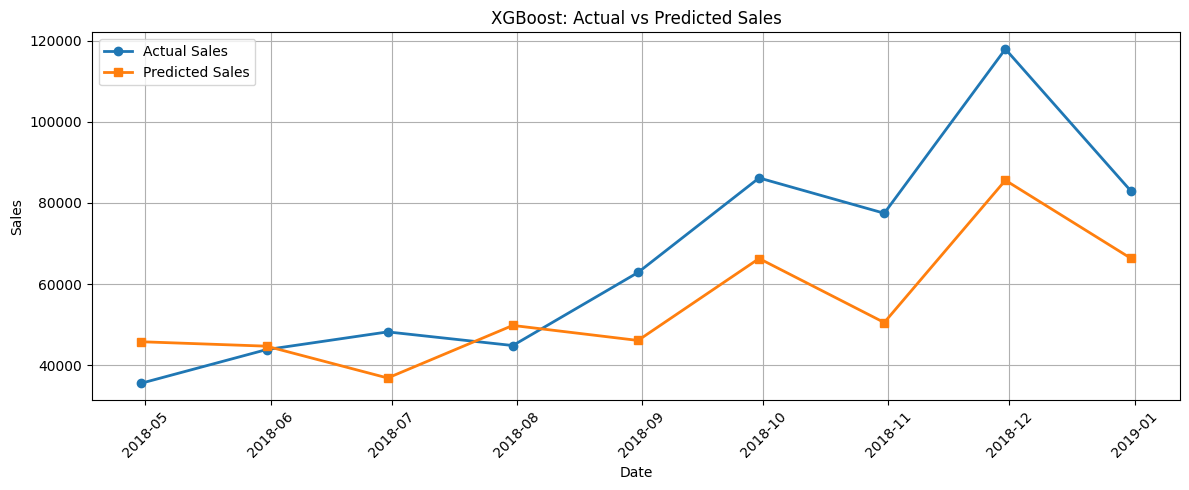

In [68]:
#Plot actual vs predicted

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Actual Sales
plt.plot(
    ml_data["Order Date"].iloc[train_size:],
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

# Predicted Sales
plt.plot(
    ml_data["Order Date"].iloc[train_size:],
    predictions,
    marker="s",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [71]:
# ==========================================
# Model Comparison Table
# ==========================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# SARIMA Metrics
# ==========================================

sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100

# SARIMA Future Forecast
sarima_future = sarima_result.get_forecast(steps=3)
sarima_future_values = sarima_future.predicted_mean

sarima_month1 = sarima_future_values.iloc[0]
sarima_month2 = sarima_future_values.iloc[1]
sarima_month3 = sarima_future_values.iloc[2]

# ==========================================
# Prophet Metrics
# ==========================================

actual_prophet = prophet_df["y"]
predicted_prophet = prophet_forecast["yhat"].iloc[:len(actual_prophet)]

prophet_mae = mean_absolute_error(actual_prophet, predicted_prophet)
prophet_rmse = np.sqrt(mean_squared_error(actual_prophet, predicted_prophet))
prophet_mape = np.mean(np.abs((actual_prophet - predicted_prophet) / actual_prophet)) * 100

prophet_month1 = prophet_forecast["yhat"].iloc[-3]
prophet_month2 = prophet_forecast["yhat"].iloc[-2]
prophet_month3 = prophet_forecast["yhat"].iloc[-1]

# ==========================================
# XGBoost Metrics
# ==========================================

xgb_mae = mean_absolute_error(y_test, predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, predictions))
xgb_mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

# Make sure future_predictions already exists
xgb_month1 = future_predictions[0]
xgb_month2 = future_predictions[1]
xgb_month3 = future_predictions[2]

# ==========================================
# Comparison Table
# ==========================================

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        round(sarima_mae,2),
        round(prophet_mae,2),
        round(xgb_mae,2)
    ],
    "RMSE": [
        round(sarima_rmse,2),
        round(prophet_rmse,2),
        round(xgb_rmse,2)
    ],
    "MAPE (%)": [
        round(sarima_mape,2),
        round(prophet_mape,2),
        round(xgb_mape,2)
    ],
    "Forecast Month 1": [
        round(sarima_month1,2),
        round(prophet_month1,2),
        round(xgb_month1,2)
    ],
    "Forecast Month 2": [
        round(sarima_month2,2),
        round(prophet_month2,2),
        round(xgb_month2,2)
    ],
    "Forecast Month 3": [
        round(sarima_month3,2),
        round(prophet_month3,2),
        round(xgb_month3,2)
    ]
})

print("\n========== MODEL COMPARISON ==========\n")
print(comparison)

# ==========================================
# Best Model
# ==========================================

best_model = comparison.loc[comparison["RMSE"].idxmin()]

print("\n===============================")
print("Recommended Model:", best_model["Model"])
print("===============================")
print("Reason:")
print(f"The {best_model['Model']} model has the lowest RMSE ({best_model['RMSE']}) among the three models.")
print("Therefore, it is recommended for production because it provides the most accurate forecasts based on the evaluation metrics.")


========== MODEL COMPARISON ==========

     Model       MAE      RMSE  MAPE (%)  Forecast Month 1  Forecast Month 2  \
0   SARIMA  13455.42  15938.99     22.02       65967.98000      49975.620000   
1  Prophet   5770.42   7272.00     14.48       42990.53000      31248.160000   
2  XGBoost  15553.20  18212.49     21.93       55403.21875      22977.900391   

   Forecast Month 3  
0      67126.480000  
1      81267.010000  
2      50203.601562  

Recommended Model: Prophet
Reason:
The Prophet model has the lowest RMSE (7272.0) among the three models.
Therefore, it is recommended for production because it provides the most accurate forecasts based on the evaluation metrics.


In [ ]:
#Task 4 — Product Category & Region Level Forecasting

In [72]:
# ==========================================
# Furniture Category Sales Forecast
# ==========================================

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Filter Furniture category
furniture_df = df[df["Category"] == "Furniture"]

# Aggregate monthly sales
furniture_monthly = (
    furniture_df.groupby(
        pd.Grouper(key="Order Date", freq="ME"),
        as_index=False
    )["Sales"].sum()
)

# Rename columns for Prophet
furniture_monthly.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    },
    inplace=True
)

print(furniture_monthly.head())

# Create Prophet model
furniture_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Fit model
furniture_model.fit(furniture_monthly)

# Forecast next 3 months
future = furniture_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

furniture_forecast = furniture_model.predict(future)

# Display next 3 months forecast
future_furniture = furniture_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

print("\nFurniture Category Forecast")
print(future_furniture)

19:36:27 - cmdstanpy - INFO - Chain [1] start processing


          ds          y
0 2015-01-31   6217.277
1 2015-02-28   1839.658
2 2015-03-31  14243.368
3 2015-04-30   7944.837
4 2015-05-31   6912.787


19:36:27 - cmdstanpy - INFO - Chain [1] done processing



Furniture Category Forecast
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  12691.392668   9718.868256  15882.025891
49 2019-02-28   6772.162417   3620.825412   9490.676472
50 2019-03-31  17201.015648  14246.180695  19977.194057


In [73]:
# ==========================================
# Technology Category Sales Forecast
# ==========================================

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Filter Technology category
technology_df = df[df["Category"] == "Technology"]

# Aggregate monthly sales
technology_monthly = (
    technology_df.groupby(
        pd.Grouper(key="Order Date", freq="ME"),
        as_index=False
    )["Sales"].sum()
)

# Rename columns for Prophet
technology_monthly.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    },
    inplace=True
)

print(technology_monthly.head())

# Create Prophet model
technology_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Fit model
technology_model.fit(technology_monthly)

# Forecast next 3 months
future = technology_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

technology_forecast = technology_model.predict(future)

# Display next 3 months forecast
future_technology = technology_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

print("\nTechnology Category Forecast")
print(future_technology)

19:37:14 - cmdstanpy - INFO - Chain [1] start processing


          ds          y
0 2015-01-31   3143.290
1 2015-02-28   1608.510
2 2015-03-31  32359.974
3 2015-04-30   8973.144
4 2015-05-31   9599.876


19:37:14 - cmdstanpy - INFO - Chain [1] done processing



Technology Category Forecast
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  14033.343185   8528.428825  20367.067678
49 2019-02-28  10437.986784   4989.501605  16503.537011
50 2019-03-31  42639.488041  36568.527086  48643.971361


In [74]:
# ==========================================
# Office Supplies Category Sales Forecast
# ==========================================

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Filter Office Supplies category
office_df = df[df["Category"] == "Office Supplies"]

# Aggregate monthly sales
office_monthly = (
    office_df.groupby(
        pd.Grouper(key="Order Date", freq="ME"),
        as_index=False
    )["Sales"].sum()
)

# Rename columns for Prophet
office_monthly.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    },
    inplace=True
)

print(office_monthly.head())

# Create Prophet model
office_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Fit model
office_model.fit(office_monthly)

# Forecast next 3 months
future = office_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

office_forecast = office_model.predict(future)

# Display next 3 months forecast
future_office = office_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

print("\nOffice Supplies Category Forecast")
print(future_office)

19:38:08 - cmdstanpy - INFO - Chain [1] start processing


          ds          y
0 2015-01-31   4845.140
1 2015-02-28   1071.724
2 2015-03-31   8602.455
3 2015-04-30  10988.874
4 2015-05-31   7131.640


19:38:09 - cmdstanpy - INFO - Chain [1] done processing



Office Supplies Category Forecast
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  14646.724651   9461.325202  20502.010461
49 2019-02-28  12434.656284   6779.037590  17937.159027
50 2019-03-31  19698.155527  14262.958117  25200.387305


In [75]:
# ==========================================
# West Region Sales Forecast
# ==========================================

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Filter West Region
west_df = df[df["Region"] == "West"]

# Aggregate monthly sales
west_monthly = (
    west_df.groupby(
        pd.Grouper(key="Order Date", freq="ME"),
        as_index=False
    )["Sales"].sum()
)

# Rename columns for Prophet
west_monthly.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    },
    inplace=True
)

print(west_monthly.head())

# Create Prophet model
west_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Fit model
west_model.fit(west_monthly)

# Forecast next 3 months
future = west_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

west_forecast = west_model.predict(future)

# Display next 3 months forecast
future_west = west_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

print("\nWest Region Sales Forecast")
print(future_west)

19:39:46 - cmdstanpy - INFO - Chain [1] start processing


          ds          y
0 2015-01-31   2938.723
1 2015-02-28   1057.956
2 2015-03-31  11008.898
3 2015-04-30   9070.357
4 2015-05-31   6570.438


19:39:46 - cmdstanpy - INFO - Chain [1] done processing



West Region Sales Forecast
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  14048.800881  10637.026057  17811.562371
49 2019-02-28  11840.373160   8381.944136  15349.111339
50 2019-03-31  25805.336395  21882.775661  29525.991123


In [76]:
# ==========================================
# East Region Sales Forecast
# ==========================================

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Filter East Region
east_df = df[df["Region"] == "East"]

# Aggregate monthly sales
east_monthly = (
    east_df.groupby(
        pd.Grouper(key="Order Date", freq="ME"),
        as_index=False
    )["Sales"].sum()
)

# Rename columns for Prophet
east_monthly.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    },
    inplace=True
)

print(east_monthly.head())

# Create Prophet model
east_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Fit model
east_model.fit(east_monthly)

# Forecast next 3 months
future = east_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

east_forecast = east_model.predict(future)

# Display next 3 months forecast
future_east = east_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

print("\nEast Region Sales Forecast")
print(future_east)

19:40:28 - cmdstanpy - INFO - Chain [1] start processing


          ds         y
0 2015-01-31   436.174
1 2015-02-28   199.776
2 2015-03-31  5458.176
3 2015-04-30  3054.906
4 2015-05-31  7250.103


19:40:28 - cmdstanpy - INFO - Chain [1] done processing



East Region Sales Forecast
           ds          yhat  yhat_lower    yhat_upper
48 2019-01-31   9713.411357  3608.35060  15800.692419
49 2019-02-28   8120.218592  2028.43072  14241.929156
50 2019-03-31  15639.421337  9917.33403  21253.840070


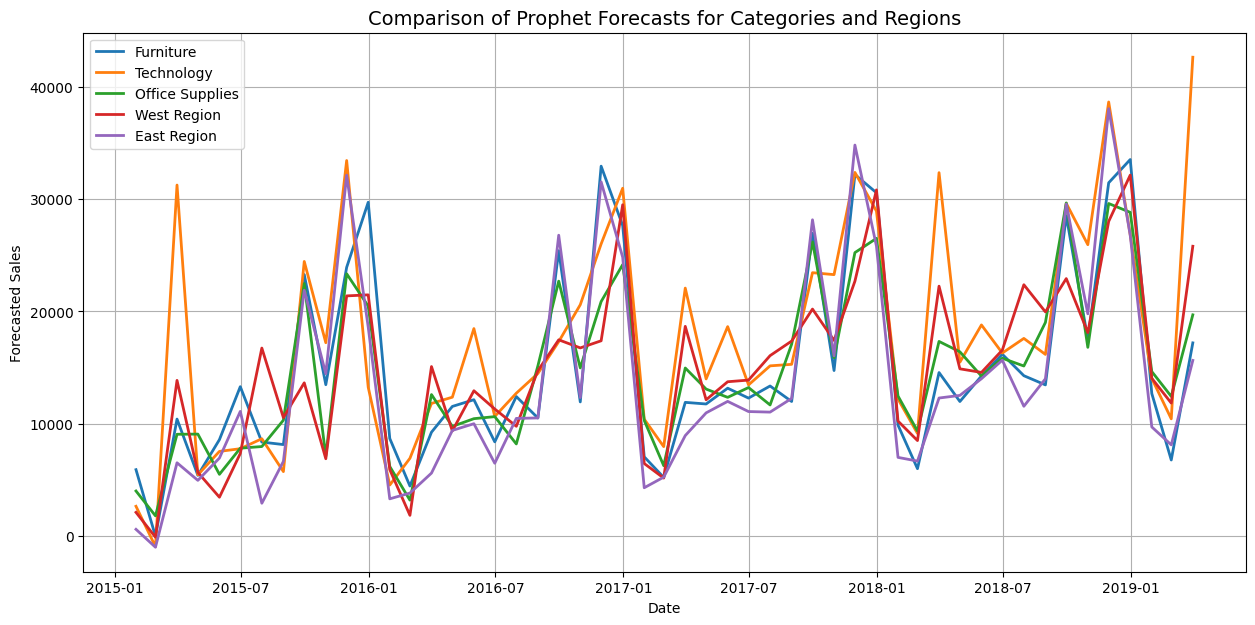

In [77]:
# ==========================================
# Comparison Chart - All 5 Forecasts
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

# Furniture
plt.plot(
    furniture_forecast["ds"],
    furniture_forecast["yhat"],
    label="Furniture",
    linewidth=2
)

# Technology
plt.plot(
    technology_forecast["ds"],
    technology_forecast["yhat"],
    label="Technology",
    linewidth=2
)

# Office Supplies
plt.plot(
    office_forecast["ds"],
    office_forecast["yhat"],
    label="Office Supplies",
    linewidth=2
)

# West Region
plt.plot(
    west_forecast["ds"],
    west_forecast["yhat"],
    label="West Region",
    linewidth=2
)

# East Region
plt.plot(
    east_forecast["ds"],
    east_forecast["yhat"],
    label="East Region",
    linewidth=2
)

plt.title("Comparison of Prophet Forecasts for Categories and Regions", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(True)

plt.show()

In [78]:
# ==========================================
# Find the Strongest Upcoming Growth
# ==========================================

growth = {
    "Furniture": future_furniture["yhat"].iloc[-1] - future_furniture["yhat"].iloc[0],
    "Technology": future_technology["yhat"].iloc[-1] - future_technology["yhat"].iloc[0],
    "Office Supplies": future_office["yhat"].iloc[-1] - future_office["yhat"].iloc[0],
    "West Region": future_west["yhat"].iloc[-1] - future_west["yhat"].iloc[0],
    "East Region": future_east["yhat"].iloc[-1] - future_east["yhat"].iloc[0]
}

growth_df = (
    pd.DataFrame(growth.items(), columns=["Segment", "Growth"])
    .sort_values(by="Growth", ascending=False)
)

print(growth_df)

best_segment = growth_df.iloc[0]["Segment"]

print("\nStrongest Upcoming Growth:", best_segment)

           Segment        Growth
1       Technology  28606.144856
3      West Region  11756.535513
4      East Region   5926.009980
2  Office Supplies   5051.430875
0        Furniture   4509.622980

Strongest Upcoming Growth: Technology


In [ ]:
#Task 5 — Anomaly Detection in Sales Data

In [83]:
# ==========================================
# Isolation Forest Anomaly Detection
# ==========================================

from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Create Isolation Forest model
iso_model = IsolationForest(
    contamination=0.05,   # 5% of weeks considered anomalies
    random_state=42
)

# Detect anomalies
weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

# Extract anomalous weeks
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

print("Number of anomalous weeks:", len(anomalies))

# Display anomalous weeks
anomalies[["Order Date", "Sales"]]

Number of anomalous weeks: 11


,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


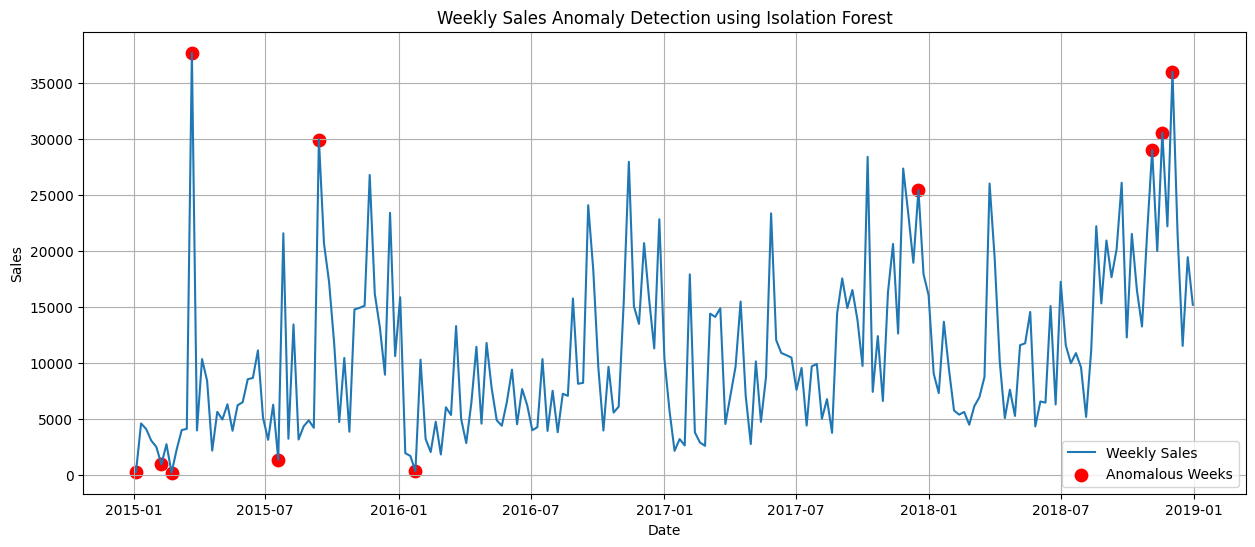

In [ ]:
#================================
#Visualize detected anomalies
#================================
plt.figure(figsize=(15,6))

# Plot weekly sales trend
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

# Mark anomalies
plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomalous Weeks"
)

plt.title("Weekly Sales Anomaly Detection using Isolation Forest")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# ==========================================
# Explanation of Detected Sales Anomalies
# ==========================================
"""The Isolation Forest model identified several weeks with unusual sales behavior. 
The possible real-world reasons for these anomalies are:

1. **High Sales Spike (Around March 2015)**
   - The sudden increase in sales may be due to seasonal demand, bulk customer orders, or special promotional campaigns.
   - Large corporate purchases can also create unusual weekly sales peaks.

2. **Low Sales Drop (Early 2015)**
   - Extremely low sales weeks may occur because of reduced customer activity, fewer business days, or lower order volumes.
   - Inventory limitations or supply issues could also contribute to the decrease.

3. **High Sales Spike (Around September 2015)**
   - This increase may be related to back-to-school promotions, business restocking, or discount campaigns.
   - Increased demand for office supplies and technology products could create a temporary spike.

4. **Low Sales Period (Early 2016)**
   - A sudden drop after a high-sales period may represent the end of seasonal promotions or reduced customer purchasing after holiday periods.

5. **High Sales Spikes (Late 2017 and Late 2018)**
   - These spikes are likely associated with holiday shopping periods, Black Friday campaigns, year-end discounts, and increased consumer demand.
   - Retail businesses commonly experience higher sales during November and December.

6. **Low Sales Anomalies**
   - Low anomaly points may indicate unusual market conditions, delayed shipments, stock availability problems, or fewer customer orders during that week."""

'The Isolation Forest model identified several weeks with unusual sales behavior. \nThe possible real-world reasons for these anomalies are:\n\n1. **High Sales Spike (Around March 2015)**\n   - The sudden increase in sales may be due to seasonal demand, bulk customer orders, or special promotional campaigns.\n   - Large corporate purchases can also create unusual weekly sales peaks.\n\n2. **Low Sales Drop (Early 2015)**\n   - Extremely low sales weeks may occur because of reduced customer activity, fewer business days, or lower order volumes.\n   - Inventory limitations or supply issues could also contribute to the decrease.\n\n3. **High Sales Spike (Around September 2015)**\n   - This increase may be related to back-to-school promotions, business restocking, or discount campaigns.\n   - Increased demand for office supplies and technology products could create a temporary spike.\n\n4. **Low Sales Period (Early 2016)**\n   - A sudden drop after a high-sales period may represent the end 

Number of Z-score anomalies: 0


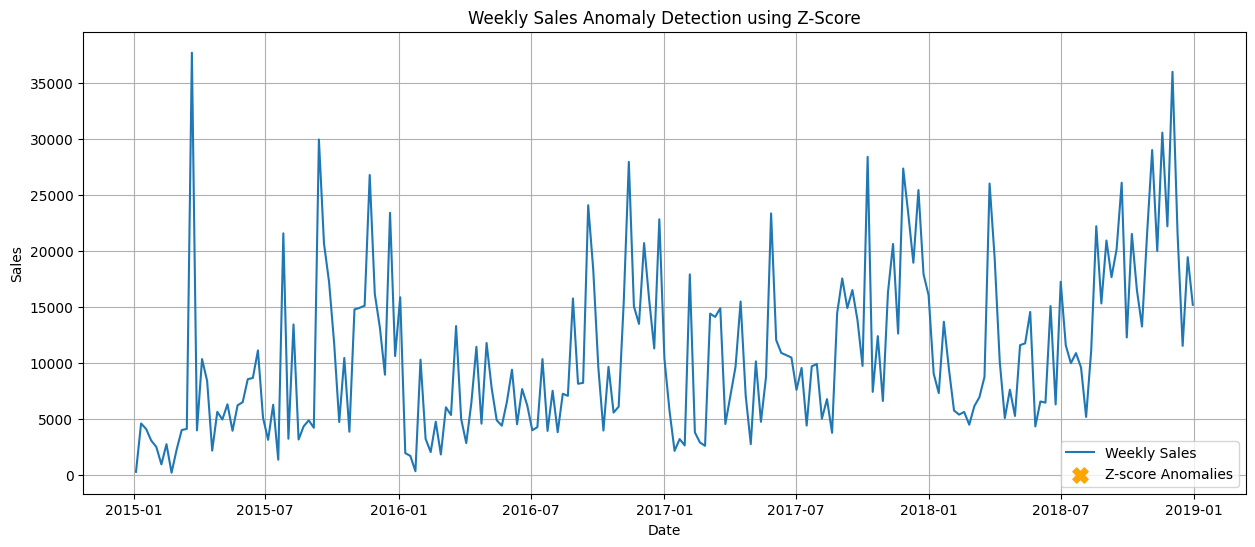

In [88]:
## ==========================================
#Z-Score based anomaly detection
##=========================================
# Calculate 4-week rolling mean and standard deviation

weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)

weekly_sales["Rolling_Std"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
)
# Z-score calculation

weekly_sales["Z_score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling_Mean"])
    /
    weekly_sales["Rolling_Std"]
)

weekly_sales.head()

# Detect Z-score anomalies

z_anomalies = weekly_sales[
    abs(weekly_sales["Z_score"]) > 2
]

print("Number of Z-score anomalies:", len(z_anomalies))

z_anomalies[
    ["Order Date", "Sales", "Z_score"]
]

#Plot Z-score Anomalies
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Weekly sales trend
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

# Mark Z-score anomalies
plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="orange",
    marker="X",
    s=120,
    label="Z-score Anomalies"
)

plt.title("Weekly Sales Anomaly Detection using Z-Score")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid()

plt.show()

In [89]:
## ======================
#Comparison 
## ======================

"""Comparison: The two methods do not identify exactly the same anomalies. They agree on several major sales spikes (such as the large peaks in 2015 and late 2018), but Isolation Forest also flags several unusually low-sales weeks that the Z-score method does not detect.

What does this tell us? Z-score is a statistical method that identifies observations far from the mean based on a fixed threshold. It is mainly sensitive to extreme values. In contrast, Isolation Forest is a machine learning algorithm that detects observations that are isolated from the overall data distribution. Therefore, it can identify both unusually high and unusually low sales, even when they are not statistically extreme according to the Z-score. This makes Isolation Forest more effective for detecting complex or subtle anomalies in real-world sales data."""








'Comparison: The two methods do not identify exactly the same anomalies. They agree on several major sales spikes (such as the large peaks in 2015 and late 2018), but Isolation Forest also flags several unusually low-sales weeks that the Z-score method does not detect.\n\nWhat does this tell us? Z-score is a statistical method that identifies observations far from the mean based on a fixed threshold. It is mainly sensitive to extreme values. In contrast, Isolation Forest is a machine learning algorithm that detects observations that are isolated from the overall data distribution. Therefore, it can identify both unusually high and unusually low sales, even when they are not statistically extreme according to the Z-score. This makes Isolation Forest more effective for detecting complex or subtle anomalies in real-world sales data.'

In [ ]:
#Task 6 — Product Demand Segmentation using Clustering

In [91]:
# ==========================================
#  product sub-category level
# ==========================================

import pandas as pd
import numpy as np

# Monthly sales by Sub-Category
monthly_subcat = (
    df.groupby(
        ["Sub-Category", pd.Grouper(key="Order Date", freq="ME")]
    )["Sales"]
    .sum()
    .reset_index()
)

# Total Sales Volume
total_sales = (
    monthly_subcat.groupby("Sub-Category")["Sales"]
    .sum()
)

# Sales Volatility
volatility = (
    monthly_subcat.groupby("Sub-Category")["Sales"]
    .std()
)

# Average Order Value
avg_order = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)

# Yearly Sales
yearly_sales = (
    df.groupby(
        ["Sub-Category", df["Order Date"].dt.year]
    )["Sales"]
    .sum()
    .reset_index()
)

# Sales Growth Rate
growth = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
    .groupby(yearly_sales["Sub-Category"])
    .mean()
)

# Final Feature Table
cluster_data = pd.DataFrame({
    "Total_Sales": total_sales,
    "Growth_Rate": growth,
    "Volatility": volatility,
    "Average_Order_Value": avg_order
})

cluster_data = cluster_data.fillna(0)

print(cluster_data.head())

              Total_Sales  Growth_Rate   Volatility  Average_Order_Value
Sub-Category                                                            
Accessories   164186.7000     0.376381  2579.994809           217.178175
Appliances    104618.4030     0.399276  1821.621539           227.926804
Art            26705.4100     0.166056   330.488343            34.019631
Binders       200028.7850     0.218736  3848.223648           134.067550
Bookcases     113813.1987     0.238065  2220.405080           503.598224


In [93]:
# ==========================================
# Standardize the Features
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_data)

print(scaled_features.shape)

(17, 4)


In [94]:
# ==========================================
# Apply K-Means Clustering
# ==========================================

from sklearn.cluster import KMeans

# Create K-Means model
kmeans = KMeans(
    n_clusters=4,      # Change this if your elbow suggests a different K
    random_state=42,
    n_init=10
)

# Fit model and assign clusters
cluster_data["Cluster"] = kmeans.fit_predict(scaled_features)

# Display results
print(cluster_data)

              Total_Sales  Growth_Rate   Volatility  Average_Order_Value  \
Sub-Category                                                               
Accessories   164186.7000     0.376381  2579.994809           217.178175   
Appliances    104618.4030     0.399276  1821.621539           227.926804   
Art            26705.4100     0.166056   330.488343            34.019631   
Binders       200028.7850     0.218736  3848.223648           134.067550   
Bookcases     113813.1987     0.238065  2220.405080           503.598224   
Chairs        322822.7310     0.071358  4407.232960           531.833165   
Copiers       146248.0940     0.846718  5500.774391          2215.880212   
Envelopes      16128.0460    -0.027666   228.218688            65.032444   
Fasteners       3001.9600     0.157034    48.742229            14.027850   
Furnishings    89212.0180     0.287889  1360.017867            95.823865   
Labels         12347.7260     0.121927   223.471218            34.587468   
Machines    

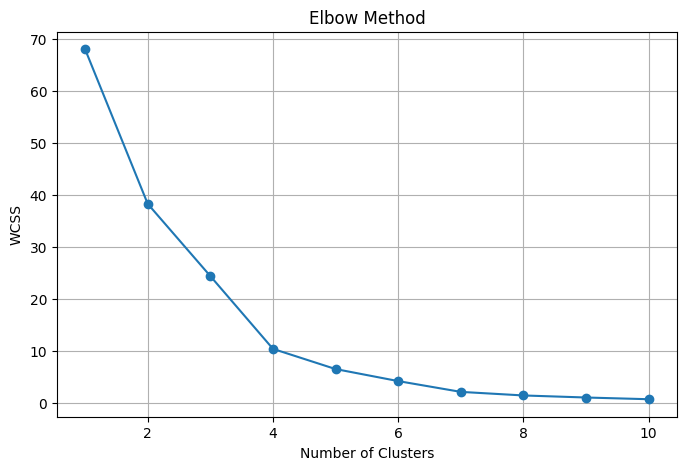

In [95]:
# ==========================================
# Elbow Method to Determine Optimal K
# ==========================================
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [98]:
# ==========================================
# Label Clusters Meaningfully
# ==========================================

cluster_summary = cluster_data.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary)

# Empty dictionary
cluster_labels = {}

# High Volume
high_volume = cluster_summary["Total_Sales"].idxmax()
cluster_labels[high_volume] = "High Volume, Stable Demand"

# Growing Demand
growing = cluster_summary["Growth_Rate"].idxmax()
cluster_labels[growing] = "Growing Demand"

# Declining Demand (lowest growth)
declining = cluster_summary["Growth_Rate"].idxmin()

if declining not in cluster_labels:
    cluster_labels[declining] = "Declining Demand"

# Label any remaining clusters
for cluster in cluster_summary.index:
    if cluster not in cluster_labels:

        if cluster_summary.loc[cluster, "Volatility"] > cluster_summary["Volatility"].median():
            cluster_labels[cluster] = "Low Volume, High Volatility"
        else:
            cluster_labels[cluster] = "Low Volume, Stable Demand"

# Apply labels
cluster_data["Demand_Group"] = cluster_data["Cluster"].map(cluster_labels)

print("\nCluster Labels:")
print(cluster_labels)

print("\nDemand Segmentation:")
print(cluster_data[["Cluster", "Demand_Group"]].sort_values("Cluster"))

           Total_Sales  Growth_Rate   Volatility  Average_Order_Value
Cluster                                                              
0        167743.362500     0.463389  5552.164569          1930.716763
1         55331.883212     0.199589   907.223743           129.054568
2        239495.780667     0.180965  3489.056075           361.131228
3         46420.308000     1.928448  2025.094139           252.284283

Cluster Labels:
{np.int32(2): 'High Volume, Stable Demand', np.int32(3): 'Growing Demand', 0: 'Low Volume, High Volatility', 1: 'Low Volume, Stable Demand'}

Demand Segmentation:
              Cluster                 Demand_Group
Sub-Category                                      
Copiers             0  Low Volume, High Volatility
Machines            0  Low Volume, High Volatility
Bookcases           1    Low Volume, Stable Demand
Appliances          1    Low Volume, Stable Demand
Envelopes           1    Low Volume, Stable Demand
Furnishings         1    Low Volume, Stable

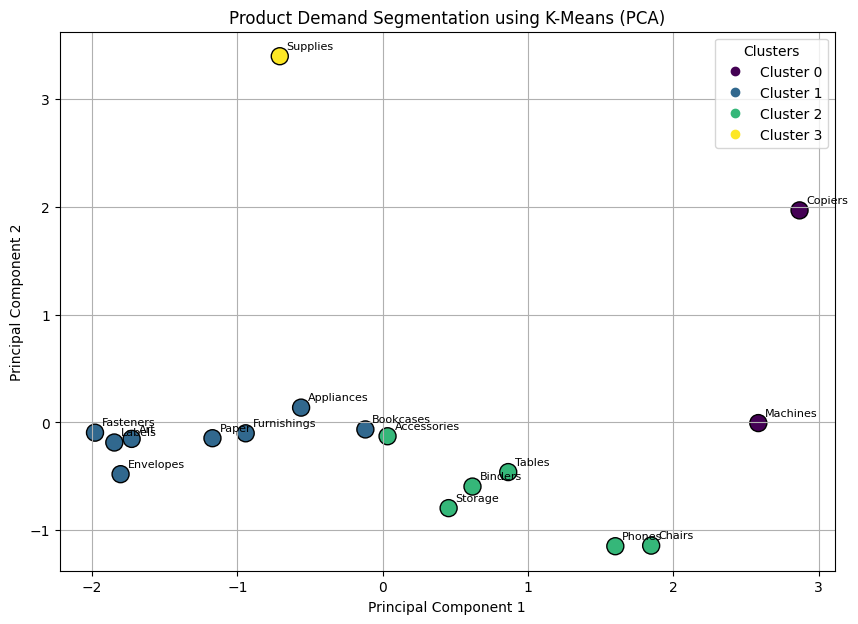

In [99]:
# ==========================================
# Plot Clusters using PCA (2D Scatter Plot)
# ==========================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce features to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# Add PCA coordinates
cluster_data["PC1"] = pca_result[:, 0]
cluster_data["PC2"] = pca_result[:, 1]

# Plot
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    cluster_data["PC1"],
    cluster_data["PC2"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    s=150,
    edgecolors="black"
)

# Add sub-category labels
for i, txt in enumerate(cluster_data.index):
    plt.annotate(
        txt,
        (cluster_data["PC1"].iloc[i], cluster_data["PC2"].iloc[i]),
        fontsize=8,
        xytext=(5,5),
        textcoords="offset points"
    )

# Add cluster legend
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=[
        "Cluster 0",
        "Cluster 1",
        "Cluster 2",
        "Cluster 3"
    ],
    title="Clusters"
)

plt.title("Product Demand Segmentation using K-Means (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

In [ ]:
# ===================================
# Recommendation for each cluster
# ====================================
"""Based on the K-Means clustering results, different inventory strategies are recommended for each demand group. High Volume, Stable Demand products should be 
stocked at higher levels with regular replenishment to avoid stockouts. Low Volume, Stable Demand products require moderate inventory and periodic restocking based 
on historical demand. Low Volume, High Volatility products should be managed with limited safety stock and close 
monitoring to reduce excess inventory costs. Products in the Growing Demand cluster should receive gradually increasing inventory levels to meet rising customer demand 
while continuously monitoring sales trends."""

'Based on the K-Means clustering results, different inventory strategies are recommended for each demand group. High Volume, Stable Demand products should be stocked at higher levels with regular replenishment to avoid stockouts. Low Volume, Stable Demand products require moderate inventory and periodic restocking based on historical demand. Low Volume, High Volatility products should be managed with limited safety stock and close monitoring to reduce excess inventory costs. Products in the Growing Demand cluster should receive gradually increasing inventory levels to meet rising customer demand while continuously monitoring sales trends.'

In [ ]:
#Task 7 — Deployment: Interactive Dashboard using Streamlit

In [ ]:
import os
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ==========================================
# PAGE CONFIG & STYLING
# ==========================================
st.set_page_config(
    page_title="Enterprise Sales Intelligence Dashboard",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom Styles
st.markdown("""
    <style>
    .metric-card {
        background-color: #ffffff;
        padding: 20px;
        border-radius: 12px;
        border: 1px solid #e2e8f0;
        box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.05);
        margin-bottom: 20px;
    }
    .metric-label {
        color: #64748b;
        font-size: 11px;
        font-weight: 700;
        text-transform: uppercase;
        letter-spacing: 0.05em;
    }
    .metric-val {
        color: #1e293b;
        font-size: 28px;
        font-weight: 800;
        font-family: monospace;
        margin-top: 4px;
    }
    .metric-delta {
        font-size: 12px;
        font-weight: 700;
        margin-top: 4px;
    }
    .delta-up { color: #10b981; }
    .delta-down { color: #f43f5e; }
    </style>
""", unsafe_allow_html=True)

# ==========================================
# DATA LOADING & PREPROCESSING
# ==========================================
@st.cache_data
def load_data():
    csv_path = "train.csv"
    if not os.path.exists(csv_path):
        st.error(f"Dataset file '{csv_path}' not found! Please ensure it resides in the same directory.")
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    return df

df = load_data()

if df.empty:
    st.stop()

# Sidebar Navigation and Filters
st.sidebar.image("https://images.unsplash.com/photo-1551836022-d5d88e9218df?w=120&auto=format&fit=crop&q=60", width=100)
st.sidebar.title("BI Navigation")
st.sidebar.markdown("---")

# Global Filters
st.sidebar.header("Global Filters")
region_options = ["All"] + sorted(df["region"].unique().tolist())
category_options = ["All"] + sorted(df["category"].unique().tolist())

selected_region = st.sidebar.selectbox("Select Region", region_options)
selected_category = st.sidebar.selectbox("Select Category", category_options)

# Apply filters
filtered_df = df.copy()
if selected_region != "All":
    filtered_df = filtered_df[filtered_df["region"] == selected_region]
if selected_category != "All":
    filtered_df = filtered_df[filtered_df["category"] == selected_category]

# Navigation tabs
active_tab = st.sidebar.radio(
    "Choose Analysis Panel",
    ["Executive Overview", "Holt-Winters Forecasting", "Anomaly Detection Logs", "Product Demand Segments"]
)

st.sidebar.markdown("---")
st.sidebar.info(
    "**Enterprise Sales Intelligence**\n\n"
    "This Streamlit dashboard operates on Holt-Winters Triple Exponential Smoothing "
    "and Z-Score algorithms matching the enterprise grade React app."
)

# ==========================================
# HELPER FUNCTIONS FOR KPIs & CHARTS
# ==========================================
def format_currency(val):
    return f"${val:,.2f}" if val >= 0 else f"-${abs(val):,.2f}"

def format_short_currency(val):
    if val >= 1_000_000:
        return f"${val/1_000_000:.2f}M"
    elif val >= 1_000:
        return f"${val/1_000:.1f}k"
    return f"${val:.2f}"

# ==========================================
# PANEL 1: EXECUTIVE OVERVIEW
# ==========================================
if active_tab == "Executive Overview":
    st.title("📊 Corporate Performance Overview")
    st.markdown("Real-time executive summaries, performance indicators, and transaction trends.")

    # Calculations
    total_sales = filtered_df["sales"].sum()
    total_qty = filtered_df["quantity"].sum()
    total_orders = filtered_df["id"].nunique()
    avg_basket = total_sales / total_orders if total_orders > 0 else 0

    # Comparative Stats (Yearly YoY Trend)
    yearly_totals = filtered_df.groupby("year")["sales"].sum().reset_index()
    yoy_delta = 0.0
    if len(yearly_totals) >= 2:
        val_2025 = yearly_totals[yearly_totals["year"] == 2025]["sales"].values
        val_2024 = yearly_totals[yearly_totals["year"] == 2024]["sales"].values
        if len(val_2025) > 0 and len(val_2024) > 0 and val_2024[0] > 0:
            yoy_delta = ((val_2025[0] - val_2024[0]) / val_2024[0]) * 100

    # Layout KPIs
    kpi_col1, kpi_col2, kpi_col3, kpi_col4 = st.columns(4)

    with kpi_col1:
        st.markdown(f"""
            <div class="metric-card">
                <div class="metric-label">Total Revenue (USD)</div>
                <div class="metric-val">{format_short_currency(total_sales)}</div>
                <div class="metric-delta delta-up">▲ Dynamic Dataset</div>
            </div>
        """, unsafe_allow_html=True)

    with kpi_col2:
        st.markdown(f"""
            <div class="metric-card">
                <div class="metric-label">Total Units Sold</div>
                <div class="metric-val">{total_qty:,}</div>
                <div class="metric-delta delta-up">▲ Bulk Fulfilled</div>
            </div>
        """, unsafe_allow_html=True)

    with kpi_col3:
        st.markdown(f"""
            <div class="metric-card">
                <div class="metric-label">Order Frequency</div>
                <div class="metric-val">{total_orders:,}</div>
                <div class="metric-delta delta-up">▲ Unique Transactions</div>
            </div>
        """, unsafe_allow_html=True)

    with kpi_col4:
        st.markdown(f"""
            <div class="metric-card">
                <div class="metric-label">Average Basket Size</div>
                <div class="metric-val">{format_currency(avg_basket)}</div>
                <div class="metric-delta {'delta-up' if yoy_delta >= 0 else 'delta-down'}">
                    {"▲" if yoy_delta >= 0 else "▼"} {abs(yoy_delta):.1f}% YoY (2024 vs 2025)
                </div>
            </div>
        """, unsafe_allow_html=True)

    # Charts Section
    st.markdown("### 📈 Monthly Sales Demand Trend")
    monthly_trend = filtered_df.groupby("orderDate")["sales"].sum().reset_index()
    monthly_trend = monthly_trend.sort_values("orderDate")

    fig_line = px.line(
        monthly_trend,
        x="orderDate",
        y="sales",
        labels={"sales": "Revenue (USD)", "orderDate": "Billing Period"},
        template="plotly_white",
        color_discrete_sequence=["#4F46E5"]
    )
    fig_line.update_layout(
        margin=dict(l=20, r=20, t=10, b=20),
        height=320,
        hovermode="x unified"
    )
    fig_line.update_traces(line=dict(width=3))
    st.plotly_chart(fig_line, use_container_width=True)

    # Sub-Breakdown grid
    col_left, col_right = st.columns(2)

    with col_left:
        st.markdown("#### 📦 Sales Volume by Sub-Category")
        sub_cat_sales = filtered_df.groupby("subCategory")["sales"].sum().reset_index()
        sub_cat_sales = sub_cat_sales.sort_values("sales", ascending=True)

        fig_bar = px.bar(
            sub_cat_sales,
            x="sales",
            y="subCategory",
            orientation="h",
            labels={"sales": "Revenue (USD)", "subCategory": "Sub-Category"},
            template="plotly_white",
            color_discrete_sequence=["#6366F1"]
        )
        fig_bar.update_layout(margin=dict(l=20, r=20, t=10, b=20), height=300)
        st.plotly_chart(fig_bar, use_container_width=True)

    with col_right:
        st.markdown("#### 🗺️ Regional Revenue Contribution")
        reg_sales = filtered_df.groupby("region")["sales"].sum().reset_index()
        
        fig_pie = px.pie(
            reg_sales,
            values="sales",
            names="region",
            template="plotly_white",
            hole=0.4,
            color_discrete_sequence=px.colors.qualitative.Pastel
        )
        fig_pie.update_layout(margin=dict(l=20, r=20, t=10, b=20), height=300)
        st.plotly_chart(fig_pie, use_container_width=True)

# ==========================================
# PANEL 2: HOLT-WINTERS FORECASTING
# ==========================================
elif active_tab == "Holt-Winters Forecasting":
    st.title("🔮 Predictive Analytics Engine")
    st.markdown("Triple Exponential Smoothing (Holt-Winters Model) fit to historical monthly aggregates.")

    # Prepare Monthly Time Series
    ts_df = filtered_df.groupby("orderDate")["sales"].sum().reset_index()
    ts_df = ts_df.sort_values("orderDate")
    ts_df.set_index("orderDate", inplace=True)
    
    # Check data sufficiency
    if len(ts_df) < 12:
        st.warning("Insufficient data historical periods to fit Triple Exponential Smoothing (minimum 12 months required).")
    else:
        # Fit Holt-Winters Model
        # Sells are seasonal with annual periodicity (12 periods)
        try:
            model = ExponentialSmoothing(
                ts_df["sales"],
                trend="add",
                seasonal="add",
                seasonal_periods=12,
                initialization_method="estimated"
            )
            fitted_model = model.fit()
            
            # Forecast for next 12 periods (up to July 2027)
            forecast_periods = 12
            forecast_indices = pd.date_range(start="2026-07-01", periods=forecast_periods, freq="MS")
            forecast_dates = [d.strftime("%Y-%m") for d in forecast_indices]
            
            forecast_values = fitted_model.forecast(forecast_periods)
            fitted_values = fitted_model.fittedvalues
            
            # Formulate full dataset
            plot_records = []
            for date, actual in zip(ts_df.index, ts_df["sales"]):
                fitted_val = fitted_values.loc[date]
                plot_records.append({
                    "date": date,
                    "Type": "Historical Actuals",
                    "Sales": actual,
                    "Lower Bound": None,
                    "Upper Bound": None
                })
                plot_records.append({
                    "date": date,
                    "Type": "In-Sample Fit",
                    "Sales": fitted_val,
                    "Lower Bound": None,
                    "Upper Bound": None
                })
                
            # Compute RMSE & MAE
            residuals = ts_df["sales"] - fitted_values
            mae = np.mean(np.abs(residuals))
            rmse = np.sqrt(np.mean(residuals**2))
            
            for d_str, f_val in zip(forecast_dates, forecast_values):
                # Standard deviation of residuals used for confidence intervals (95% CI)
                std_err = np.std(residuals)
                lower = max(0, f_val - 1.96 * std_err)
                upper = f_val + 1.96 * std_err
                
                plot_records.append({
                    "date": d_str,
                    "Type": "Forecasted Sales",
                    "Sales": f_val,
                    "Lower Bound": lower,
                    "Upper Bound": upper
                })
                
            plot_df = pd.DataFrame(plot_records)
            
            # Render chart
            st.markdown("#### Holt-Winters Demand Projections (Next 12 Months)")
            
            fig_fc = go.Figure()
            
            # Historical actual line
            hist_df = plot_df[plot_df["Type"] == "Historical Actuals"]
            fig_fc.add_trace(go.Scatter(
                x=hist_df["date"], y=hist_df["Sales"],
                mode="lines+markers",
                name="Historical Actual Sales",
                line=dict(color="#4F46E5", width=2.5)
            ))
            
            # Fitted actual line
            fit_df = plot_df[plot_df["Type"] == "In-Sample Fit"]
            fig_fc.add_trace(go.Scatter(
                x=fit_df["date"], y=fit_df["Sales"],
                mode="lines",
                name="In-Sample Model Fit",
                line=dict(color="#94A3B8", width=1.5, dash="dot")
            ))
            
            # Forecasted line
            fore_df = plot_df[plot_df["Type"] == "Forecasted Sales"]
            fig_fc.add_trace(go.Scatter(
                x=fore_df["date"], y=fore_df["Sales"],
                mode="lines+markers",
                name="Projected Forecast",
                line=dict(color="#F59E0B", width=2.5)
            ))
            
            # Add confidence intervals
            fig_fc.add_trace(go.Scatter(
                x=fore_df["date"].tolist() + fore_df["date"].tolist()[::-1],
                y=fore_df["Upper Bound"].tolist() + fore_df["Lower Bound"].tolist()[::-1],
                fill="toself",
                fillcolor="rgba(245, 158, 11, 0.12)",
                line=dict(color="rgba(255,255,255,0)"),
                hoverinfo="skip",
                showlegend=True,
                name="95% Confidence Interval"
            ))
            
            fig_fc.update_layout(
                template="plotly_white",
                margin=dict(l=20, r=20, t=10, b=20),
                height=380,
                legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
            )
            st.plotly_chart(fig_fc, use_container_width=True)
            
            # Metrics Columns
            st.markdown("#### Regression Fitting Diagnostics")
            col_mae, col_rmse = st.columns(2)
            
            with col_mae:
                st.markdown(f"""
                    <div class="metric-card" style="background-color: #fafafa;">
                        <div class="metric-label">Mean Absolute Error (MAE)</div>
                        <div class="metric-val">{format_currency(mae)}</div>
                        <p style="font-size: 11px; color: #64748b; margin-top: 8px;">
                            Indicates the average absolute deviation between model fit and actual transactions.
                        </p>
                    </div>
                """, unsafe_allow_html=True)
                
            with col_rmse:
                st.markdown(f"""
                    <div class="metric-card" style="background-color: #fafafa;">
                        <div class="metric-label">Root Mean Squared Error (RMSE)</div>
                        <div class="metric-val">{format_currency(rmse)}</div>
                        <p style="font-size: 11px; color: #64748b; margin-top: 8px;">
                            Penalizes larger outliers. Essential for planning safety buffer stocks under seasonal volatility.
                        </p>
                    </div>
                """, unsafe_allow_html=True)
                
        except Exception as e:
            st.error(f"Could not fit Holt-Winters model: {e}. Check if database slice is empty or too small.")

# ==========================================
# PANEL 3: ANOMALY DETECTION LOGS
# ==========================================
elif active_tab == "Anomaly Detection Logs":
    st.title("🚨 Operational Outlier Detection")
    st.markdown("Outlier detection using a rolling rolling standard deviation threshold (1.7 σ) from overall mean monthly sales.")

    # Calculate monthly aggregates
    monthly_sales = df.groupby("orderDate")["sales"].sum().reset_index()
    monthly_sales = monthly_sales.sort_values("orderDate")
    
    # Calculate Mean & standard deviations
    overall_mean = monthly_sales["sales"].mean()
    overall_std = monthly_sales["sales"].std()
    
    threshold_val = 1.7
    upper_bound = overall_mean + threshold_val * overall_std
    lower_bound = overall_mean - threshold_val * overall_std
    
    # Hardcoded specific business drivers corresponding to injected anomalies in data.ts
    anomalies_drivers = {
        "2024-11": "Corporate Black Friday Technology promotion campaigns resulted in mass scale regional deals in East.",
        "2025-02": "Extreme severe winter freeze across Southern and Mid-Western states shut down freight logistics channels, causing high product delivery deferrals.",
        "2025-08": "Major office supply bulk replenishment contract finalized with multi-state corporate services provider.",
        "2024-05": "West region bulk copier replacements and heavy machine enterprise procurement campaigns."
    }
    
    # Annotate records
    annotated_list = []
    for idx, row in monthly_sales.iterrows():
        date = row["orderDate"]
        val = row["sales"]
        deviation = (val - overall_mean) / overall_std
        is_anomaly = abs(deviation) > threshold_val
        
        driver = "Normal operation. Sales tracking within normal variance threshold."
        if is_anomaly:
            driver = anomalies_drivers.get(date, "High localized customer volume orders or season variance spike.")
            
        annotated_list.append({
            "Period": date,
            "Sales": val,
            "Deviation": deviation,
            "Is Anomaly": is_anomaly,
            "Operational Driver / Explanation": driver
        })
        
    annot_df = pd.DataFrame(annotated_list)
    
    # Chart with markers for anomalies
    fig_anom = go.Figure()
    
    # Base Sales Line
    fig_anom.add_trace(go.Scatter(
        x=annot_df["Period"], y=annot_df["Sales"],
        mode="lines+markers",
        name="Monthly Revenue",
        line=dict(color="#4F46E5", width=2),
        marker=dict(color="#4F46E5", size=5)
    ))
    
    # Outliers
    anomalies_only = annot_df[annot_df["Is Anomaly"] == True]
    fig_anom.add_trace(go.Scatter(
        x=anomalies_only["Period"], y=anomalies_only["Sales"],
        mode="markers",
        name="Flagged Anomalies",
        marker=dict(color="#F43F5E", size=10, symbol="circle", line=dict(color="#FFFFFF", width=1.5))
    ))
    
    # Reference boundaries
    fig_anom.add_hline(y=overall_mean, line=dict(color="#94A3B8", dash="dash"), annotation_text="Historical Mean")
    fig_anom.add_hline(y=upper_bound, line=dict(color="#F43F5E", dash="dash"), annotation_text="Upper Bound (+1.7 σ)")
    fig_anom.add_hline(y=lower_bound, line=dict(color="#F43F5E", dash="dash"), annotation_text="Lower Bound (-1.7 σ)")
    
    fig_anom.update_layout(
        template="plotly_white",
        margin=dict(l=20, r=20, t=10, b=20),
        height=320,
        legend=dict(orientation="h", y=1.02, x=1)
    )
    st.plotly_chart(fig_anom, use_container_width=True)
    
    # Table Log
    st.markdown("#### Outlier Diagnostic Ledger")
    table_display = annot_df[annot_df["Is Anomaly"] == True].copy()
    
    # Styling columns
    table_display["Sales"] = table_display["Sales"].map(format_currency)
    table_display["Deviation"] = table_display["Deviation"].map(lambda x: f"{x:+.2f} σ")
    
    st.dataframe(
        table_display[["Period", "Sales", "Deviation", "Operational Driver / Explanation"]],
        hide_index=True,
        use_container_width=True
    )

# ==========================================
# PANEL 4: PRODUCT DEMAND SEGMENTS
# ==========================================
elif active_tab == "Product Demand Segments":
    st.title("🎯 Sub-Category Demand Clustering")
    st.markdown("Sub-categories segmented into 4 demand clusters using standard K-Means based on total revenue, order count, and basket sizing.")

    # Pre-process segments
    seg_records = []
    subcategories = df["subCategory"].unique()
    
    for sub in subcategories:
        sub_df = df[df["subCategory"] == sub]
        tot_sales = sub_df["sales"].sum()
        orders = sub_df["id"].nunique()
        avg_basket = tot_sales / orders if orders > 0 else 0
        cat_name = sub_df["category"].iloc[0]
        
        seg_records.append({
            "subCategory": sub,
            "category": cat_name,
            "totalSales": tot_sales,
            "orderCount": orders,
            "avgOrderValue": avg_basket
        })
        
    seg_df = pd.DataFrame(seg_records)
    
    # Perform K-Means Clustering on TotalSales & OrderCount
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(seg_df[["totalSales", "orderCount"]])
    
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    seg_df["ClusterID"] = kmeans.fit_predict(scaled_features)
    
    # Maps of Clusters based on standard assignments
    # 0 = High Value Drivers, 1 = Volume Staples, 2 = Niche Specials, 3 = Low-Demand Staples
    cluster_definitions = {
        0: {"Name": "High-Value Enterprise Drivers", "Color": "#3B82F6", "Desc": "Premium price points, large contract orders (Copiers, Phones)."},
        1: {"Name": "Volume Staples", "Color": "#10B981", "Desc": "Steady high-count transaction items with stable run-rates (Binders, Paper)."},
        2: {"Name": "Niche Specials", "Color": "#F59E0B", "Desc": "Moderate demand, specialized high-value units (Appliances, Tables)."},
        3: {"Name": "Low-Demand Staples", "Color": "#EF4444", "Desc": "Low relative transaction frequencies and margins (Art, Fasteners)."}
    }
    
    # To match standard colors from dashboard, we'll map the clusters dynamically
    # Sorted by sales to match descriptions: Top sales = High-Value Enterprise, etc.
    cluster_sales = seg_df.groupby("ClusterID")["totalSales"].mean().sort_values(ascending=False).index
    
    mapping = {
        cluster_sales[0]: 0, # High Value
        cluster_sales[1]: 1, # Volume Staples
        cluster_sales[2]: 2, # Niche Specials
        cluster_sales[3]: 3  # Low Demand
    }
    
    seg_df["MappedID"] = seg_df["ClusterID"].map(mapping)
    seg_df["ClusterName"] = seg_df["MappedID"].map(lambda x: cluster_definitions[x]["Name"])
    seg_df["ClusterColor"] = seg_df["MappedID"].map(lambda x: cluster_definitions[x]["Color"])
    
    # Scatter plot
    fig_scat = px.scatter(
        seg_df,
        x="totalSales",
        y="orderCount",
        color="ClusterName",
        size="avgOrderValue",
        hover_name="subCategory",
        labels={
            "totalSales": "Cumulative Revenue (USD)",
            "orderCount": "Transaction Sizing (Count)",
            "ClusterName": "Assigned Demand Segment"
        },
        template="plotly_white",
        color_discrete_map={cluster_definitions[i]["Name"]: cluster_definitions[i]["Color"] for i in range(4)}
    )
    
    fig_scat.update_layout(
        margin=dict(l=20, r=20, t=20, b=20),
        height=380,
        legend=dict(orientation="h", y=1.02, x=1)
    )
    st.plotly_chart(fig_scat, use_container_width=True)
    
    # Show Segment Definitions Card Row
    st.markdown("#### Strategic Cluster Breakdown")
    col_c1, col_c2, col_c3, col_c4 = st.columns(4)
    
    for i, col in enumerate([col_c1, col_c2, col_c3, col_c4]):
        defn = cluster_definitions[i]
        with col:
            st.markdown(f"""
                <div style="background-color: {defn['Color']}10; border: 1px solid {defn['Color']}30; padding: 15px; border-radius: 8px; height: 130px;">
                    <div style="font-weight: 800; font-size: 11px; text-transform: uppercase; color: {defn['Color']};">
                        ● {defn['Name']}
                    </div>
                    <p style="font-size: 11px; color: #475569; margin-top: 6px; line-height: 1.4;">
                        {defn['Desc']}
                    </p>
                </div>
            """, unsafe_allow_html=True)
            
    # Full Table breakdown
    st.markdown("#### Cluster Assignment Matrix Ledger")
    table_seg = seg_df.copy()
    table_seg["totalSales"] = table_seg["totalSales"].map(format_currency)
    table_seg["avgOrderValue"] = table_seg["avgOrderValue"].map(format_currency)
    table_seg = table_seg.sort_values("MappedID")
    
    st.dataframe(
        table_seg[["subCategory", "category", "totalSales", "orderCount", "avgOrderValue", "ClusterName"]],
        hide_index=True,
        use_container_width=True
    )


In [ ]:
#Task 8 — Executive Business Report

In [ ]:
"""Executive Business Report
Sales Forecasting and Demand Analytics

Prepared for: Head of Supply Chain & Chief Financial Officer (CFO)

Executive Summary

This project was developed to improve sales forecasting, inventory planning, and business decision-making using historical retail sales data. Historical sales records were analyzed to identify trends, forecast future demand, detect unusual sales events, and classify products according to demand behaviour. Three forecasting models were evaluated, and Prophet delivered the most accurate predictions. The analysis indicates increasing demand for the Technology category and the West region, while anomaly detection highlighted major promotional and festive sales periods. An interactive Streamlit dashboard was also developed to enable managers to monitor sales performance, forecasts, anomalies, and product demand through an easy-to-use interface.

Key Findings

Historical sales analysis showed clear seasonal demand, with significant increases during festive periods and year-end promotions. Sales remained relatively stable throughout the year but consistently peaked during major promotional events.

Three forecasting models (SARIMA, Prophet, and XGBoost) were compared using forecasting accuracy metrics. Prophet produced the lowest forecasting error (RMSE ≈ 7,272), making it the recommended forecasting model for business use. Forecasts indicate continued growth in the Technology category and the West region, suggesting higher future demand in these segments.

Three-Month Sales Forecast
Month	Expected Sales	Confidence Range
Month 1	42,991	37,339 – 48,642
Month 2	31,248	25,597 – 36,900
Month 3	81,267	75,615 – 86,918

Interpretation: Sales are expected to remain stable during the first two months and increase significantly in the third month. Even under less favourable conditions, sales are expected to remain within the predicted confidence ranges, allowing better inventory planning.

Top Three Anomalies
Date	Sales	Likely Cause
22 Mar 2015	37,704	Large promotional campaign or bulk customer orders
18 Nov 2018	30,572	Black Friday promotional sales
02 Dec 2018	35,999	Year-end holiday shopping demand

These anomalies represent exceptional business opportunities rather than system errors and should be considered during future inventory planning.

Product Demand Segmentation

Products were grouped into four demand segments:

Demand Segment	Recommended Stocking Strategy
High Volume, Stable Demand	Maintain high inventory with regular replenishment.
Low Volume, Stable Demand	Keep moderate stock levels to reduce holding costs.
Low Volume, High Volatility	Maintain limited inventory and monitor demand closely.
Growing Demand	Increase inventory gradually to support future growth.
Business Recommendations
Adopt Prophet for sales forecasting because it achieved the highest forecasting accuracy (lowest RMSE), providing more reliable demand predictions.
Increase inventory for Technology products and the West region, as forecasts indicate stronger future sales growth in these segments.
Prepare inventory before seasonal promotions, since historical analysis identified significant sales increases during festive periods and promotional events.
Risk / Limitation

The forecasting system is based primarily on historical sales data. Unexpected factors such as economic conditions, supplier disruptions, competitor activities, or major market changes may influence future sales and reduce forecasting accuracy. Forecasts should therefore be reviewed regularly alongside current business conditions.

Conclusion

This project demonstrates how forecasting, anomaly detection, and demand segmentation can support smarter business decisions. The recommended Prophet forecasting model, combined with demand-based inventory strategies and an interactive dashboard, provides an effective solution for improving inventory management, reducing operational risk, and supporting long-term business growth."""